In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model, tree, naive_bayes

In [16]:
df = pd.read_excel("data/dados_cerveja_nota.xlsx")
df

,id,cerveja,nota
0,1,1,0.75
1,2,1,3.00
2,3,2,1.75
3,4,3,1.75
4,5,4,4.20
5,6,4,6.50
6,7,5,2.90
7,8,6,6.20
8,9,6,7.00
9,10,7,6.20


In [17]:
df['aprovado'] = (df['nota'] > 5).astype(int)
df

,id,cerveja,nota,aprovado
0,1,1,0.75,0
1,2,1,3.00,0
2,3,2,1.75,0
3,4,3,1.75,0
4,5,4,4.20,0
5,6,4,6.50,1
6,7,5,2.90,0
7,8,6,6.20,1
8,9,6,7.00,1
9,10,7,6.20,1


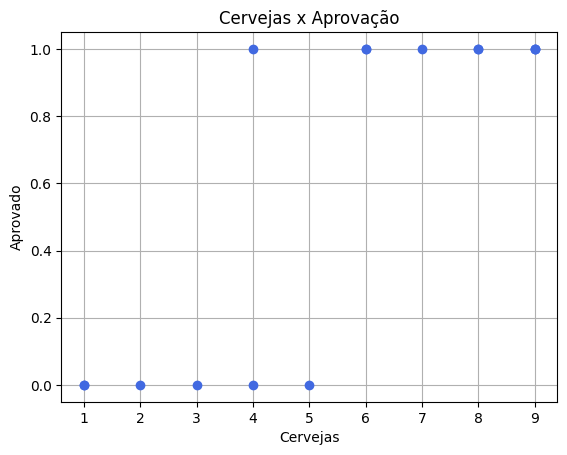

In [18]:
plt.plot(df['cerveja'], df['aprovado'], 'o', color='royalblue')
plt.grid(True)
plt.title("Cervejas x Aprovação")
plt.xlabel("Cervejas")
plt.ylabel("Aprovado")
plt.show()

In [19]:
reg = linear_model.LogisticRegression(penalty=None, fit_intercept=True)

reg.fit(df[['cerveja']], df['aprovado'])

/home/davi/Documentos/GitHub/ml-2025-teomewhy/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

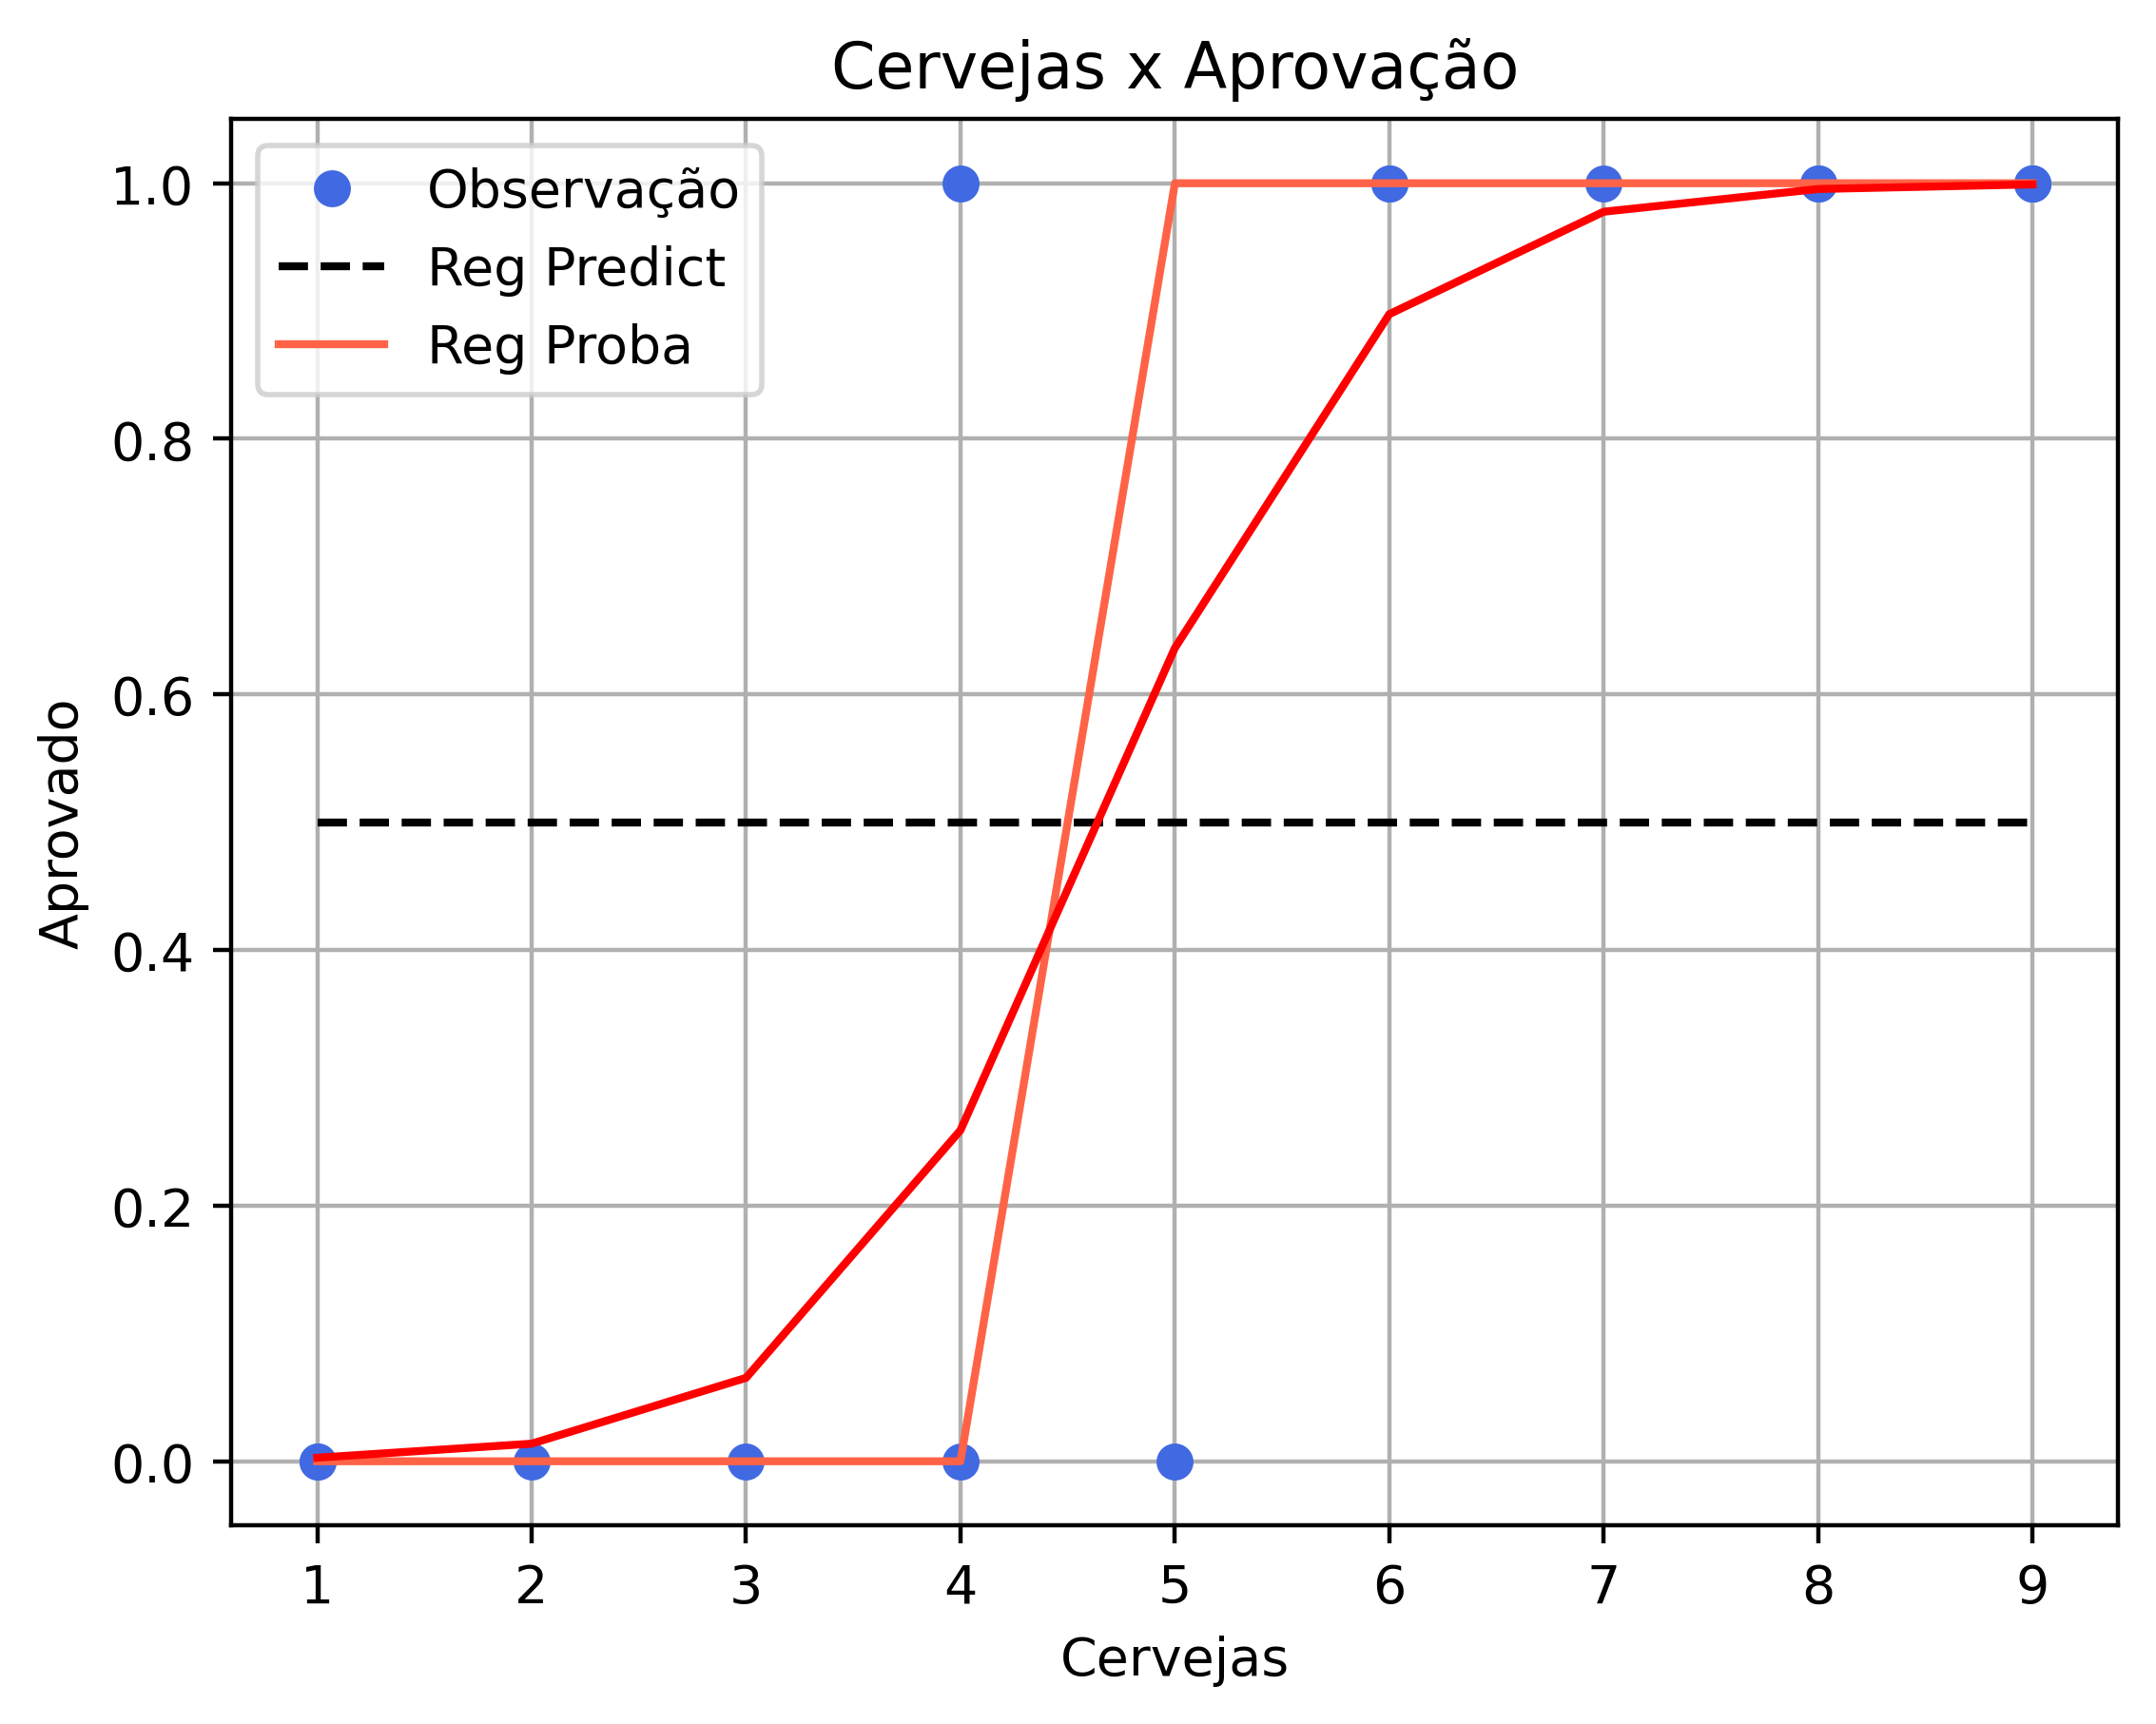

In [20]:
reg_predict = reg.predict(df[['cerveja']].drop_duplicates())
reg_prob = reg.predict_proba(df[['cerveja']].drop_duplicates())[:, 1]

plt.figure(dpi=400)
plt.plot(df['cerveja'], df['aprovado'], 'o', color='royalblue')
plt.grid(True)
plt.title("Cervejas x Aprovação")
plt.xlabel("Cervejas")
plt.ylabel("Aprovado")
plt.hlines(0.5, xmin=1, xmax=9, linestyles="--", colors="black")
plt.plot(df['cerveja'].drop_duplicates(), reg_predict, color='tomato')
plt.plot(df['cerveja'].drop_duplicates(), reg_prob, color='red')
plt.legend(["Observação", "Reg Predict", "Reg Proba"])
plt.show()

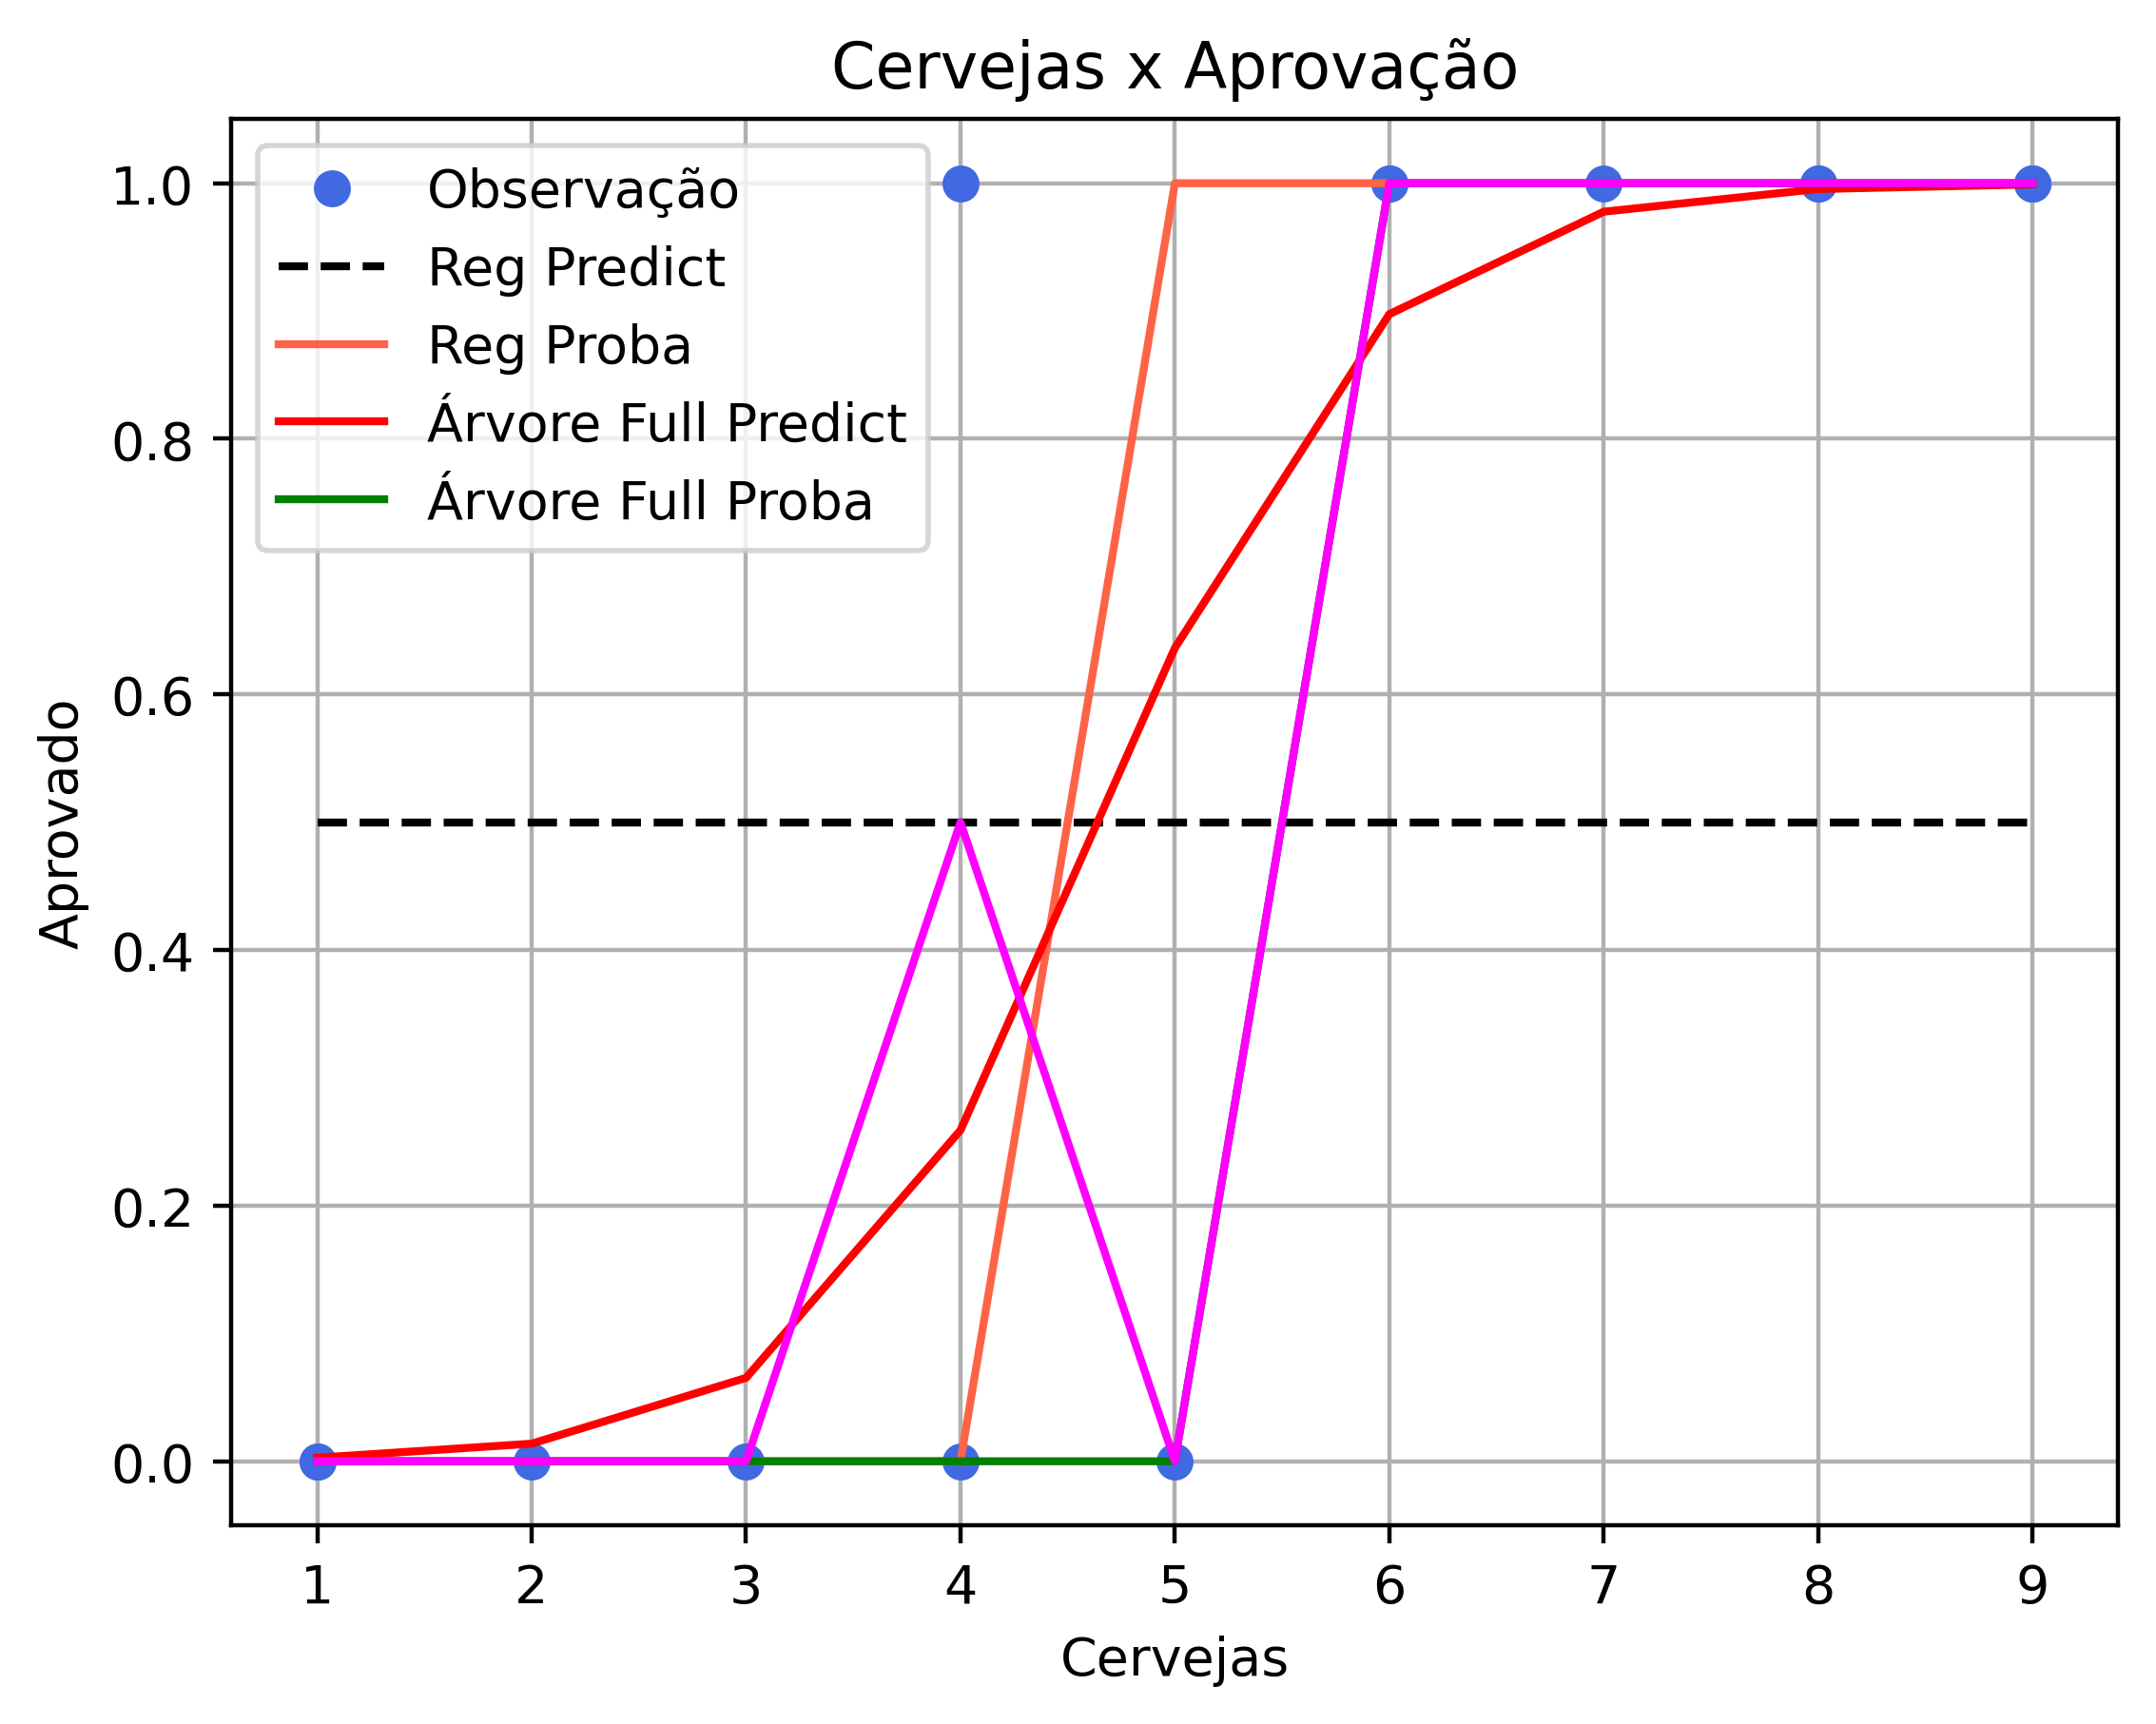

In [21]:
reg_predict = reg.predict(df[['cerveja']].drop_duplicates())
reg_prob = reg.predict_proba(df[['cerveja']].drop_duplicates())[:, 1]

arvore_full = tree.DecisionTreeClassifier(random_state=42)
arvore_full.fit(df[['cerveja']], df['aprovado'])
arvore_full_predict = arvore_full.predict(df[['cerveja']].drop_duplicates())
arvore_full_proba = arvore_full.predict_proba(df[['cerveja']].drop_duplicates())[:, 1]

plt.figure(dpi=400)
plt.plot(df['cerveja'], df['aprovado'], 'o', color='royalblue')
plt.grid(True)
plt.title("Cervejas x Aprovação")
plt.xlabel("Cervejas")
plt.ylabel("Aprovado")
plt.hlines(0.5, xmin=1, xmax=9, linestyles="--", colors="black")

plt.plot(df['cerveja'].drop_duplicates(), reg_predict, color='tomato')
plt.plot(df['cerveja'].drop_duplicates(), reg_prob, color='red')

plt.plot(df['cerveja'].drop_duplicates(), arvore_full_predict, color='green')
plt.plot(df['cerveja'].drop_duplicates(), arvore_full_proba, color='magenta')


plt.legend(["Observação", 
    "Reg Predict", 
    "Reg Proba",
    "Árvore Full Predict",
    "Árvore Full Proba"])
plt.show()

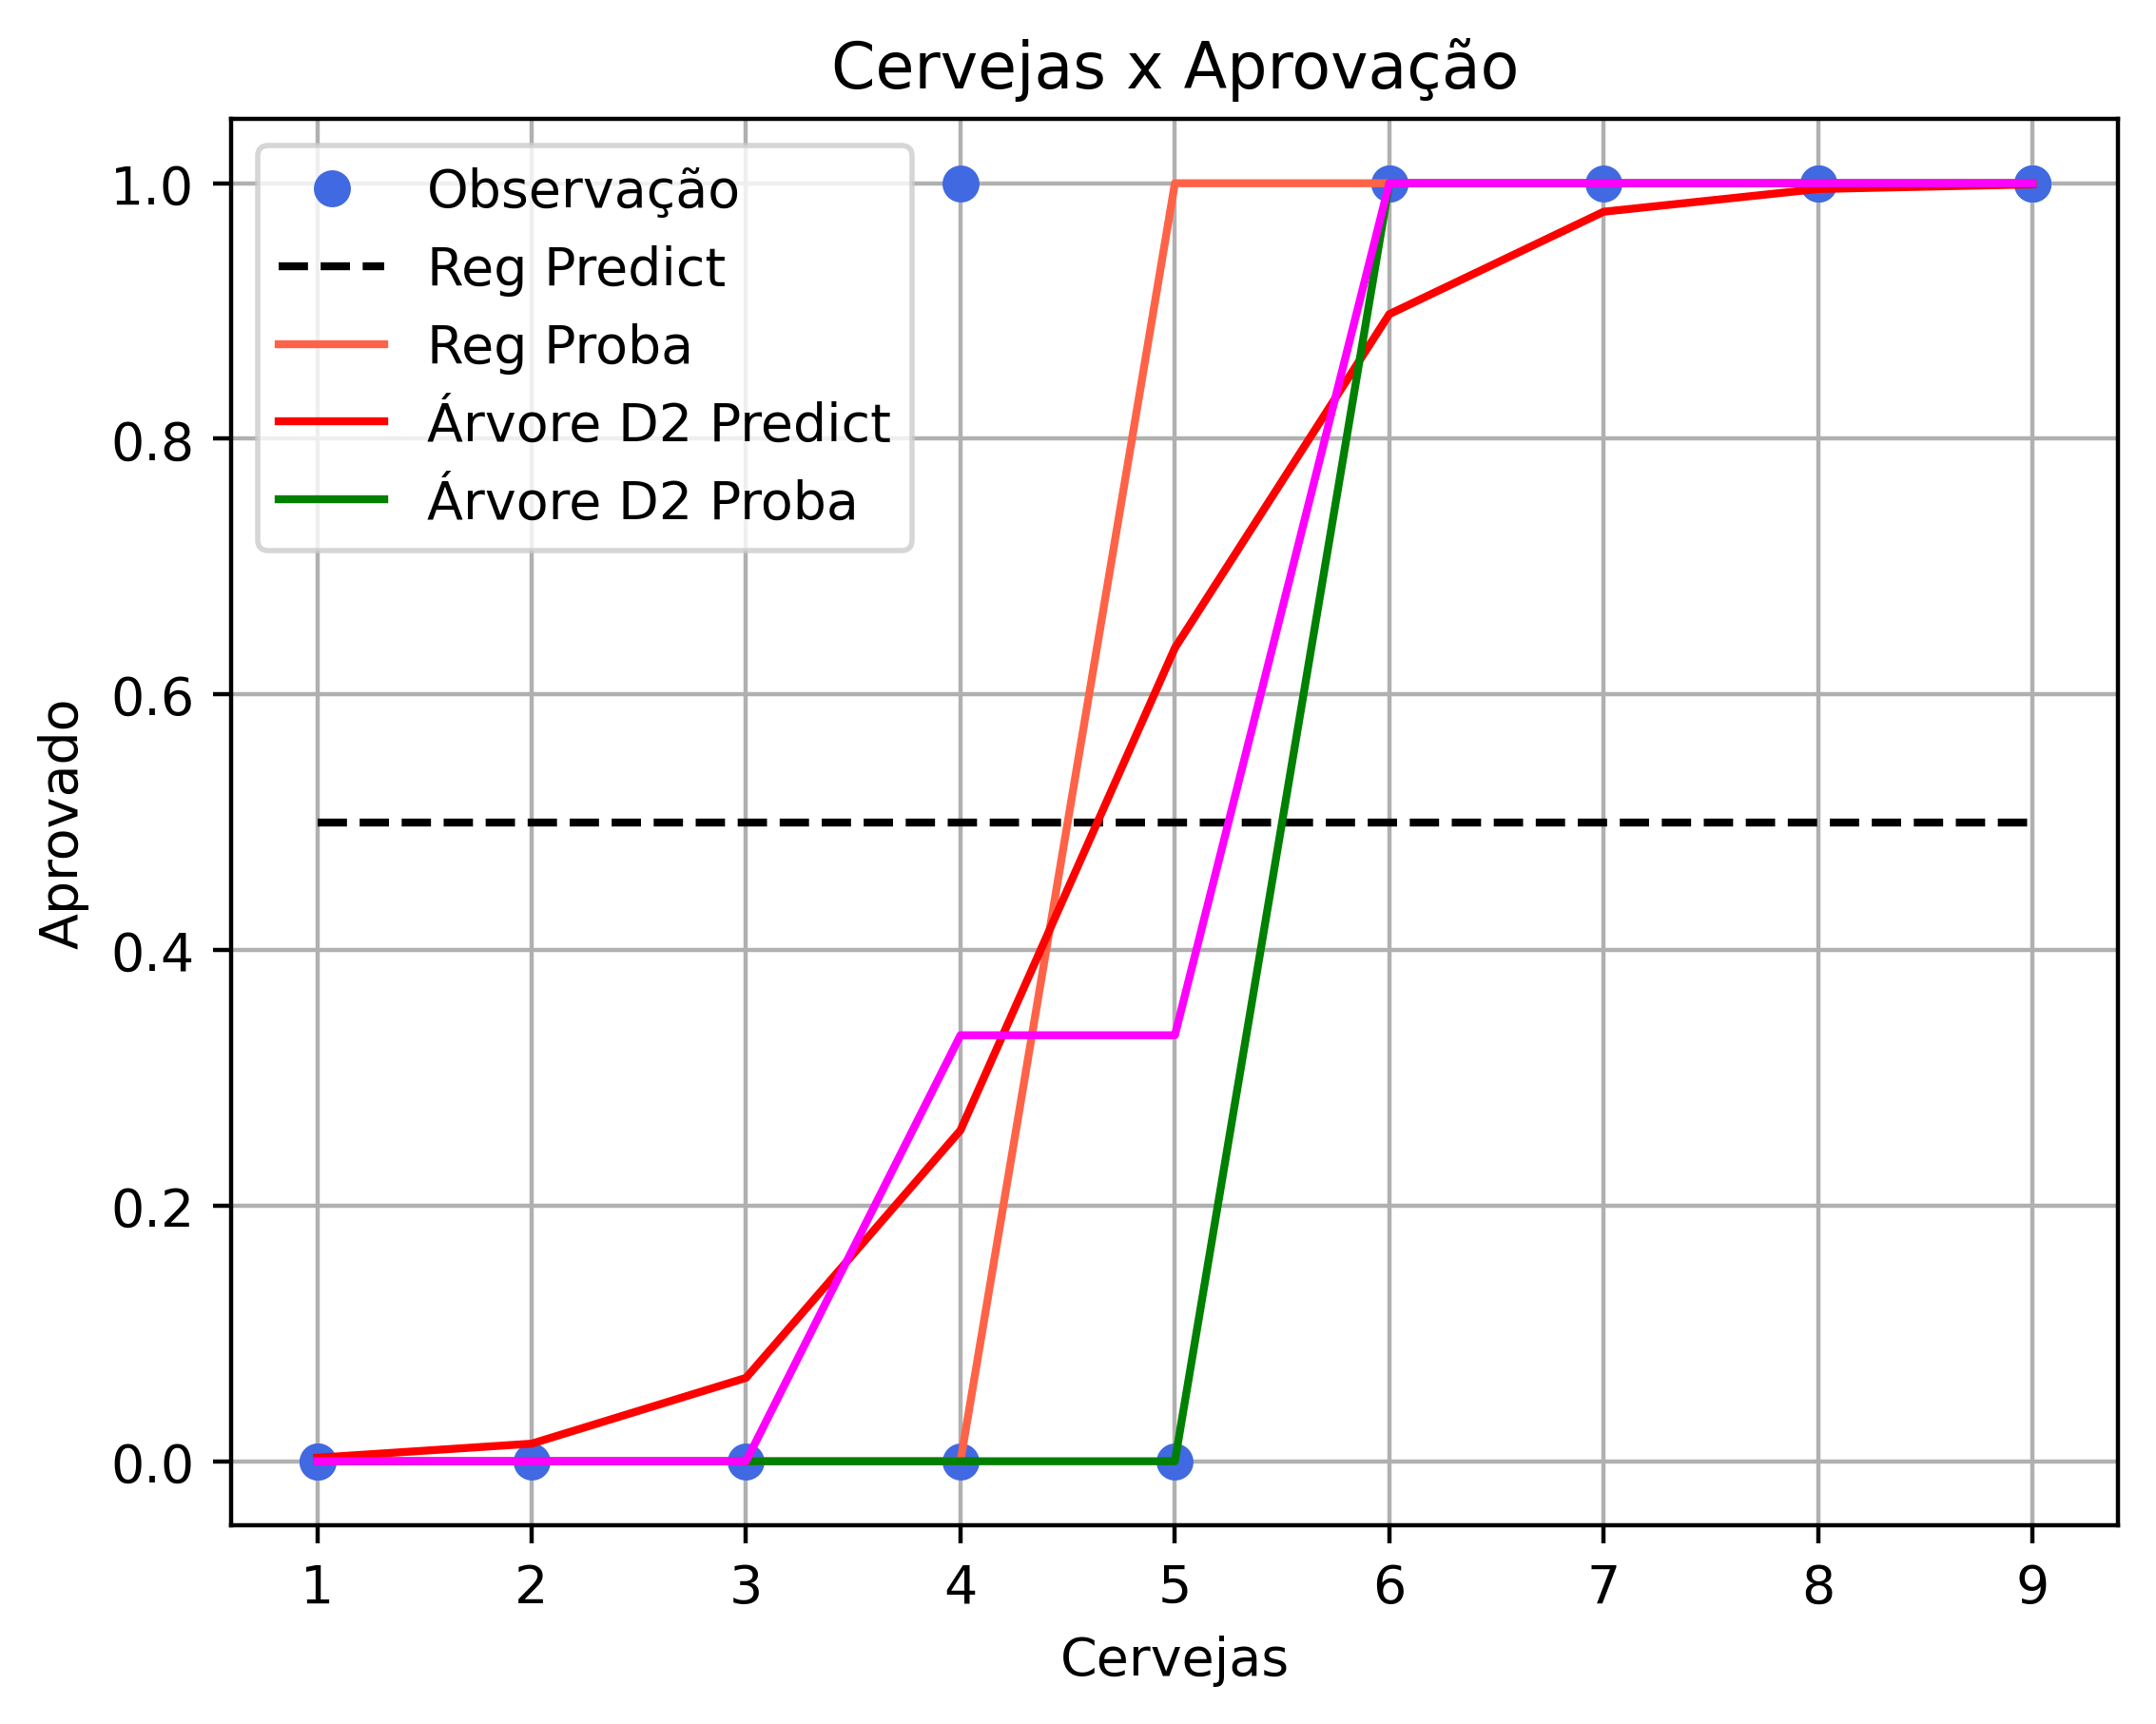

In [22]:
reg_predict = reg.predict(df[['cerveja']].drop_duplicates())
reg_prob = reg.predict_proba(df[['cerveja']].drop_duplicates())[:, 1]

arvore_d2 = tree.DecisionTreeClassifier(random_state=42, max_depth=2)
arvore_d2.fit(df[['cerveja']], df['aprovado'])
arvore_d2_predict = arvore_d2.predict(df[['cerveja']].drop_duplicates())
arvore_d2_proba = arvore_d2.predict_proba(df[['cerveja']].drop_duplicates())[:, 1]

plt.figure(dpi=400)
plt.plot(df['cerveja'], df['aprovado'], 'o', color='royalblue')
plt.grid(True)
plt.title("Cervejas x Aprovação")
plt.xlabel("Cervejas")
plt.ylabel("Aprovado")
plt.hlines(0.5, xmin=1, xmax=9, linestyles="--", colors="black")

plt.plot(df['cerveja'].drop_duplicates(), reg_predict, color='tomato')
plt.plot(df['cerveja'].drop_duplicates(), reg_prob, color='red')

plt.plot(df['cerveja'].drop_duplicates(), arvore_d2_predict, color='green')
plt.plot(df['cerveja'].drop_duplicates(), arvore_d2_proba, color='magenta')


plt.legend(["Observação", 
    "Reg Predict", 
    "Reg Proba",
    "Árvore D2 Predict",
    "Árvore D2 Proba"])
plt.show()

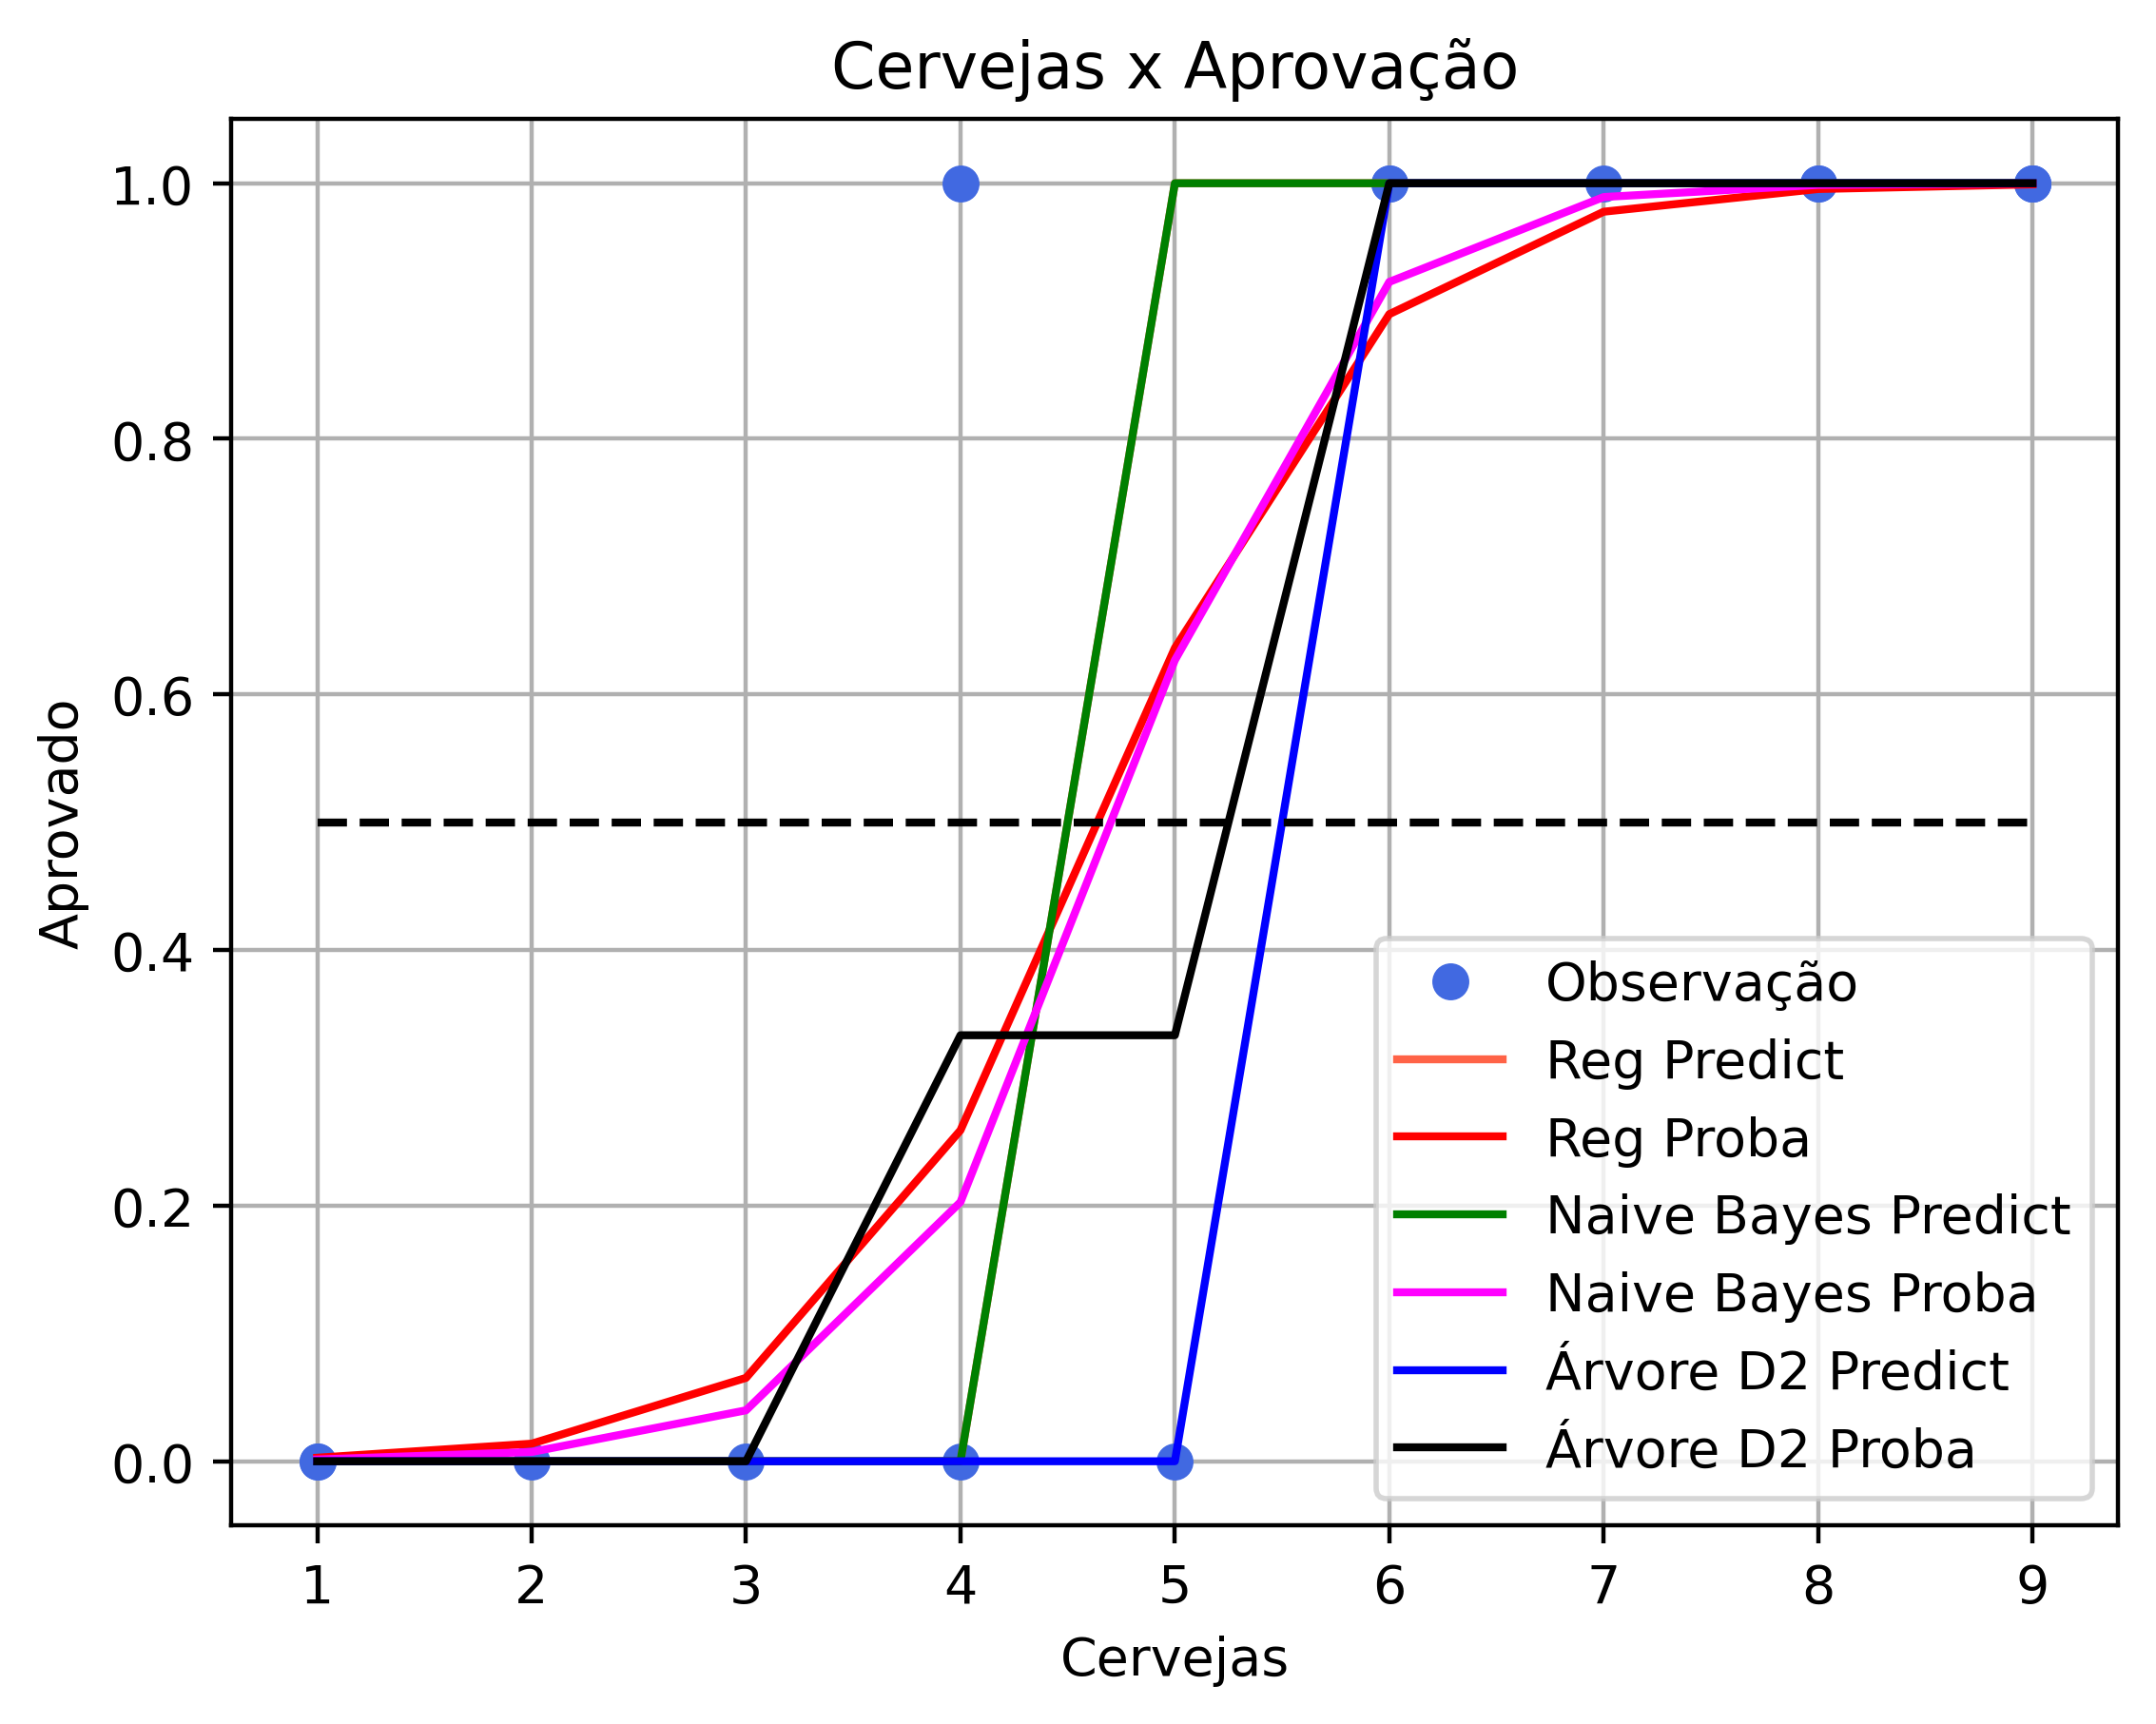

In [24]:
reg_predict = reg.predict(df[['cerveja']].drop_duplicates())
reg_prob = reg.predict_proba(df[['cerveja']].drop_duplicates())[:, 1]

arvore_d2 = tree.DecisionTreeClassifier(random_state=42, max_depth=2)
arvore_d2.fit(df[['cerveja']], df['aprovado'])
arvore_d2_predict = arvore_d2.predict(df[['cerveja']].drop_duplicates())
arvore_d2_proba = arvore_d2.predict_proba(df[['cerveja']].drop_duplicates())[:, 1]

nb = naive_bayes.GaussianNB()
nb.fit(df[['cerveja']], df['aprovado'])
nb_predict = nb.predict(df[['cerveja']].drop_duplicates())
nb_proba = nb.predict_proba(df[['cerveja']].drop_duplicates())[:, 1]

plt.figure(dpi=400)
plt.plot(df['cerveja'], df['aprovado'], 'o', color='royalblue')
plt.grid(True)
plt.title("Cervejas x Aprovação")
plt.xlabel("Cervejas")
plt.ylabel("Aprovado")

plt.plot(df['cerveja'].drop_duplicates(), reg_predict, color='tomato')
plt.plot(df['cerveja'].drop_duplicates(), reg_prob, color='red')

plt.plot(df['cerveja'].drop_duplicates(), nb_predict, color='green')
plt.plot(df['cerveja'].drop_duplicates(), nb_proba, color='magenta')


plt.plot(df['cerveja'].drop_duplicates(), arvore_d2_predict, color='blue')
plt.plot(df['cerveja'].drop_duplicates(), arvore_d2_proba, color='black')

plt.hlines(0.5, xmin=1, xmax=9, linestyles="--", colors="black")

plt.legend(["Observação", 
    "Reg Predict", 
    "Reg Proba",
    "Naive Bayes Predict",
    "Naive Bayes Proba",
    "Árvore D2 Predict",
    "Árvore D2 Proba"])
plt.show()